# Loan approval predictor

This notebook builds a model to **predict loan approval of applicant**
using **Python, Pandas, Matplotlib, and Scikit-learn**.

> **Dataset Available:** https://www.kaggle.com/datasets/madhansing/bank-loan2/code


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


## 1️⃣ Data Loading & Inspection
Load the bank-loan dataset and review its structure.

Goals:
- Identify feature types (numeric vs categorical)
- Check for missing values
- Verify the target column (loan approval status)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/data/loan.csv'
df = pd.read_csv(path)


## 2️⃣ Data Cleaning & Imputation
Handle missing values to ensure the model receives complete data.

- **Numeric columns**: Use median imputation to reduce the effect of outliers.
- **Categorical columns**: Use most-frequent (mode) imputation to preserve common categories.

In [4]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education  

## 3️⃣ Feature Encoding
Convert categorical variables to numeric.

- OneHotEncoder transforms text categories into dummy variables.
- `handle_unknown='ignore'` ensures unseen categories in the test set will not cause errors.

In [5]:
cat_cols = df.select_dtypes(include="object").columns.drop("Loan_Status")
num_cols = df.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


## 4️⃣ Train/Test Split
Split the dataset into 80% training and 20% testing sets.

- `stratify=y` keeps the same class balance (approved vs. not-approved) in both splits.

In [6]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"].map({"Y": 1, "N": 0})  # convert to 1/0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 5️⃣ Handling Class Imbalance
Loan approvals are usually imbalanced (more approvals than rejections).

- Compute class weights so the model pays more attention to the minority class (loan rejections).
- This helps improve recall for the minority class.

In [7]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),   # <-- use np.array instead of [0, 1]
    y=y_train
)

weights = {0: class_weights[0], 1: class_weights[1]}



## 6️⃣ Model Pipeline
Build a Scikit-learn Pipeline:

1. Preprocess data (imputation + encoding)
2. Train a RandomForestClassifier with class weights to address imbalance

In [8]:
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight=weights
    ))
])

clf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight={0: np.float64(1.594155844155844),
                                                      1: np.float64(0.728486646884273)},
                                        n_estimators=200, random_state=42))])

## 7 Evaluation
Evaluate the model on the test set:

- **Precision**: Of all predicted approvals, how many are truly approved.
- **Recall**: Of all actual approvals, how many were correctly predicted.
- **F1-score**: Harmonic mean of precision and recall.
- Display a **confusion matrix** to visualize true vs. false predictions.

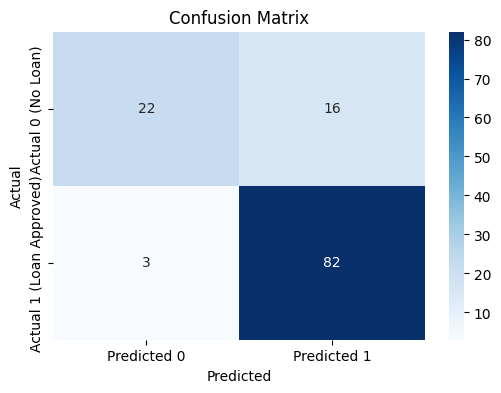

              precision    recall  f1-score   support

           0      0.880     0.579     0.698        38
           1      0.837     0.965     0.896        85

    accuracy                          0.846       123
   macro avg      0.858     0.772     0.797       123
weighted avg      0.850     0.846     0.835       123



In [9]:

import seaborn as sns
import matplotlib.pyplot as plt


# Predictions
y_pred = clf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a labeled DataFrame for clarity
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 (No Loan)", "Actual 1 (Loan Approved)"],
    columns=["Predicted 0", "Predicted 1"]
)

# Display as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Detailed classification report
print(classification_report(y_test, y_pred, digits=3))



## 9️⃣ Interpretation of Results
Summarize key findings:

- High recall for approved loans indicates most eligible borrowers are correctly identified.
- Lower recall for rejections shows some risky applications slip through.
- Overall accuracy around ~85% is solid, but business goals may require tuning to reduce false approvals.